In [ ]:
# Energy Consumption & Demand Analysis

## 1. Data Understanding

This notebook focuses on understanding the energy consumption dataset before performing data cleaning, exploratory data analysis, and predictive modeling.

### Objectives
- Understand the structure of the dataset
- Identify important variables
- Check data types
- Identify missing values
- Check duplicate records
- Generate basic statistical summaries
- Understand the time-related information

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Environment is working!")

Matplotlib is building the font cache; this may take a moment.


Pandas: 3.0.6
NumPy: 2.4.6
Environment is working!


In [ ]:
## 2. Load the Dataset
file_path = "data/raw/household_power_consumption.txt"

df_sample = pd.read_csv(
    file_path,
    sep=";",
    nrows=10000,
    na_values="?"
)

df_sample.head()



,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [6]:
df_sample.shape


(10000, 9)

In [7]:
df_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   10000 non-null  str    
 1   Time                   10000 non-null  str    
 2   Global_active_power    9998 non-null   float64
 3   Global_reactive_power  9998 non-null   float64
 4   Voltage                9998 non-null   float64
 5   Global_intensity       9998 non-null   float64
 6   Sub_metering_1         9998 non-null   float64
 7   Sub_metering_2         9998 non-null   float64
 8   Sub_metering_3         9998 non-null   float64
dtypes: float64(7), str(2)
memory usage: 703.3 KB


In [8]:
df_sample.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000,9998.000000
mean,1.744016,0.118801,241.085660,7.376535,0.885277,2.079816,8.242849
std,1.339906,0.111449,3.673675,5.644862,5.480215,7.675109,8.735647
min,0.194000,0.000000,228.910000,0.800000,0.000000,0.000000,0.000000
25%,0.388000,0.000000,238.500000,1.800000,0.000000,0.000000,0.000000
50%,1.478000,0.100000,241.550000,6.200000,0.000000,0.000000,0.000000
75%,2.561500,0.178000,243.920000,10.800000,0.000000,1.000000,17.000000
max,7.884000,0.724000,249.480000,34.200000,40.000000,73.000000,20.000000


In [9]:
df_sample.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='str')

In [10]:
df_sample.head(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
5,16/12/2006,17:29:00,3.520,0.522,235.02,15.0,0.0,2.0,17.0
6,16/12/2006,17:30:00,3.702,0.520,235.09,15.8,0.0,1.0,17.0
7,16/12/2006,17:31:00,3.700,0.520,235.22,15.8,0.0,1.0,17.0
8,16/12/2006,17:32:00,3.668,0.510,233.99,15.8,0.0,1.0,17.0
9,16/12/2006,17:33:00,3.662,0.510,233.86,15.8,0.0,2.0,16.0


In [11]:
df_sample.dtypes

Date                         str
Time                         str
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

In [12]:
df_sample.isnull().sum()

Date                     0
Time                     0
Global_active_power      2
Global_reactive_power    2
Voltage                  2
Global_intensity         2
Sub_metering_1           2
Sub_metering_2           2
Sub_metering_3           2
dtype: int64

In [14]:
df_sample["Datetime"] = pd.to_datetime(
    df_sample["Date"] + " " + df_sample["Time"],
    dayfirst=True
)

df_sample.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [15]:
df_sample["Datetime"].dtype

dtype('<M8[us]')

In [16]:
print("Start:", df_sample["Datetime"].min())
print("End:", df_sample["Datetime"].max())

Start: 2006-12-16 17:24:00
End: 2006-12-23 16:03:00


In [17]:
df_sample["Year"] = df_sample["Datetime"].dt.year
df_sample["Month"] = df_sample["Datetime"].dt.month
df_sample["Day"] = df_sample["Datetime"].dt.day
df_sample["Hour"] = df_sample["Datetime"].dt.hour
df_sample["DayOfWeek"] = df_sample["Datetime"].dt.dayofweek

In [18]:
df_sample["Is_Weekend"] = df_sample["DayOfWeek"] >= 5

In [19]:
df_sample[
    ["Datetime", "Year", "Month", "Day", "Hour", "DayOfWeek", "Is_Weekend"]
].head(10)

,Datetime,Year,Month,Day,Hour,DayOfWeek,Is_Weekend
0,2006-12-16 17:24:00,2006,12,16,17,5,True
1,2006-12-16 17:25:00,2006,12,16,17,5,True
2,2006-12-16 17:26:00,2006,12,16,17,5,True
3,2006-12-16 17:27:00,2006,12,16,17,5,True
4,2006-12-16 17:28:00,2006,12,16,17,5,True
5,2006-12-16 17:29:00,2006,12,16,17,5,True
6,2006-12-16 17:30:00,2006,12,16,17,5,True
7,2006-12-16 17:31:00,2006,12,16,17,5,True
8,2006-12-16 17:32:00,2006,12,16,17,5,True
9,2006-12-16 17:33:00,2006,12,16,17,5,True


In [20]:
energy_columns = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

df_sample[energy_columns].head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
df_sample[energy_columns].describe().T
#.T make data easier to read by transposing the data frame

,count,mean,std,min,25%,50%,75%,max
Global_active_power,9998.0,1.744016,1.339906,0.194,0.388,1.478,2.5615,7.884
Global_reactive_power,9998.0,0.118801,0.111449,0.000,0.000,0.100,0.1780,0.724
Voltage,9998.0,241.085660,3.673675,228.910,238.500,241.550,243.9200,249.480
Global_intensity,9998.0,7.376535,5.644862,0.800,1.800,6.200,10.8000,34.200
Sub_metering_1,9998.0,0.885277,5.480215,0.000,0.000,0.000,0.0000,40.000
Sub_metering_2,9998.0,2.079816,7.675109,0.000,0.000,0.000,1.0000,73.000
Sub_metering_3,9998.0,8.242849,8.735647,0.000,0.000,0.000,17.0000,20.000


In [24]:
df_sample["Global_active_power"].describe()

count    9998.000000
mean        1.744016
std         1.339906
min         0.194000
25%         0.388000
50%         1.478000
75%         2.561500
max         7.884000
Name: Global_active_power, dtype: float64

In [25]:
print("Minimum consumption:", df_sample["Global_active_power"].min())
print("Maximum consumption:", df_sample["Global_active_power"].max())
print("Average consumption:", df_sample["Global_active_power"].mean())

Minimum consumption: 0.194
Maximum consumption: 7.884
Average consumption: 1.744016403280656


In [26]:
missing_values = df_sample.isnull().sum()

missing_values[missing_values > 0]

Global_active_power      2
Global_reactive_power    2
Voltage                  2
Global_intensity         2
Sub_metering_1           2
Sub_metering_2           2
Sub_metering_3           2
dtype: int64

In [27]:
duplicate_count = df_sample.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [28]:
print(
    "Zero consumption records:",
    (df_sample["Global_active_power"] == 0).sum()
)

Zero consumption records: 0


In [29]:
numeric_columns = df_sample.select_dtypes(include=np.number).columns

(df_sample[numeric_columns] < 0).sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Year                     0
Month                    0
Day                      0
Hour                     0
DayOfWeek                0
dtype: int64

## 3. Initial Data Understanding Summary

### Dataset
- Source: UCI Machine Learning Repository
- Dataset: Individual Household Electric Power Consumption
- Current sample: 10,000 records

### Key observations
- The dataset contains timestamped electricity measurements.
- `Global_active_power` will be used as the primary energy consumption variable.
- Date and Time were combined into a `Datetime` variable.
- Additional time-based features were created: Year, Month, Day, Hour, DayOfWeek, and Is_Weekend.
- Data quality checks were performed for missing values, duplicates, zero consumption, and negative values.

### Next Step
The next stage is to prepare the complete dataset and perform exploratory data analysis (EDA) to identify energy consumption patterns and peak-demand periods.

In [30]:
#Now we will load the complete dataset for further analysis.

file_path = "data/raw/household_power_consumption.txt"

df = pd.read_csv(
    file_path,
    sep=";",
    na_values="?",
    low_memory=False
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 2075259
Columns: 9


In [31]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 142.5 MB


In [32]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [33]:
df.tail()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.00,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.70,3.8,0.0,0.0,0.0
2075258,26/11/2010,21:02:00,0.932,0.0,239.55,3.8,0.0,0.0,0.0


In [34]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [35]:
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True
)

In [36]:
df["Year"] = df["Datetime"].dt.year
df["Month"] = df["Datetime"].dt.month
df["Day"] = df["Datetime"].dt.day
df["Hour"] = df["Datetime"].dt.hour
df["DayOfWeek"] = df["Datetime"].dt.dayofweek
df["Is_Weekend"] = df["DayOfWeek"] >= 5

In [37]:
df = df.sort_values("Datetime").reset_index(drop=True)

In [38]:
df[[
    "Datetime",
    "Global_active_power",
    "Voltage",
    "Global_intensity",
    "Hour",
    "DayOfWeek",
    "Is_Weekend"
]].head()

,Datetime,Global_active_power,Voltage,Global_intensity,Hour,DayOfWeek,Is_Weekend
0,2006-12-16 17:24:00,4.216,234.84,18.4,17,5,True
1,2006-12-16 17:25:00,5.360,233.63,23.0,17,5,True
2,2006-12-16 17:26:00,5.374,233.29,23.0,17,5,True
3,2006-12-16 17:27:00,5.388,233.74,23.0,17,5,True
4,2006-12-16 17:28:00,3.666,235.68,15.8,17,5,True


In [39]:
#Cleaning the dataset by removing rows with missing values in critical columns
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
Datetime                     0
Year                         0
Month                        0
Day                          0
Hour                         0
DayOfWeek                    0
Is_Weekend                   0
dtype: int64

In [ ]:
#errors="coerce" converts anything that isn't a valid number into NaN.
measurement_columns = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in measurement_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [41]:
df[measurement_columns].isnull().sum()

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [42]:
df_clean = df.dropna(subset=measurement_columns).copy()

In [43]:
print("Original rows:", len(df))
print("Clean rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 2075259
Clean rows: 2049280
Rows removed: 25979


In [44]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [ ]:
#we're creating df_clean, we're keeping the original df unchanged and creating:
df_clean.info()


<class 'pandas.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 16 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   str           
 1   Time                   str           
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   Datetime               datetime64[us]
 10  Year                   int32         
 11  Month                  int32         
 12  Day                    int32         
 13  Hour                   int32         
 14  DayOfWeek              int32         
 15  Is_Weekend             bool          
dtypes: bool(1), datetime64[us](1), float64(7), int32(5), str(2)
memory usage: 213.0 MB


Convert power to energy consumption
Global_active_power is measured in kilowatts (kW) and each observation represents approximately one minute.
So:
Energy (kWh) = Power (kW) × Time (hours)
For one minute:
1 minute = 1/60 hour

In [48]:
df_clean["Energy_kWh"] = df_clean["Global_active_power"] / 60

df_clean[
    ["Datetime", "Global_active_power", "Energy_kWh"]
].head(10)

,Datetime,Global_active_power,Energy_kWh
0,2006-12-16 17:24:00,4.216,0.070267
1,2006-12-16 17:25:00,5.360,0.089333
2,2006-12-16 17:26:00,5.374,0.089567
3,2006-12-16 17:27:00,5.388,0.089800
4,2006-12-16 17:28:00,3.666,0.061100
5,2006-12-16 17:29:00,3.520,0.058667
6,2006-12-16 17:30:00,3.702,0.061700
7,2006-12-16 17:31:00,3.700,0.061667
8,2006-12-16 17:32:00,3.668,0.061133
9,2006-12-16 17:33:00,3.662,0.061033


In [49]:
total_energy = df_clean["Energy_kWh"].sum()

print("Total energy consumption:", round(total_energy, 2), "kWh")

Total energy consumption: 37283.75 kWh


In [53]:
daily_energy = (
    df_clean
    .set_index("Datetime")["Energy_kWh"]
    .resample("D")
    .sum()
    .reset_index()
)

daily_energy.head()


,Datetime,Energy_kWh
0,2006-12-16,20.152933
1,2006-12-17,56.507667
2,2006-12-18,36.730433
3,2006-12-19,27.769900
4,2006-12-20,37.095800


In [54]:
daily_energy.shape

(1442, 2)

idxmin() vs min()

idxmin() is a Pandas function that finds the position/index of the row containing the smallest value.
for example 

daily_energy["Energy_kWh"].min()

returns the smallest value:
12.4


Whereas

daily_energy["Energy_kWh"].idxmin()

returns the index/row location where the smallest value occurs:

3

Same for idxmax() vs max()

In [ ]:
highest_day = daily_energy.loc[
    daily_energy["Energy_kWh"].idxmax()
]

highest_day

Datetime      2006-12-23 00:00:00
Energy_kWh              79.556433
Name: 7, dtype: object

In [56]:
lowest_day = daily_energy.loc[
    daily_energy["Energy_kWh"].idxmin()
]

lowest_day

Datetime      2007-04-29 00:00:00
Energy_kWh                    0.0
Name: 134, dtype: object

In [57]:
print(
    "Average daily consumption:",
    round(daily_energy["Energy_kWh"].mean(), 2),
    "kWh"
)

Average daily consumption: 25.86 kWh


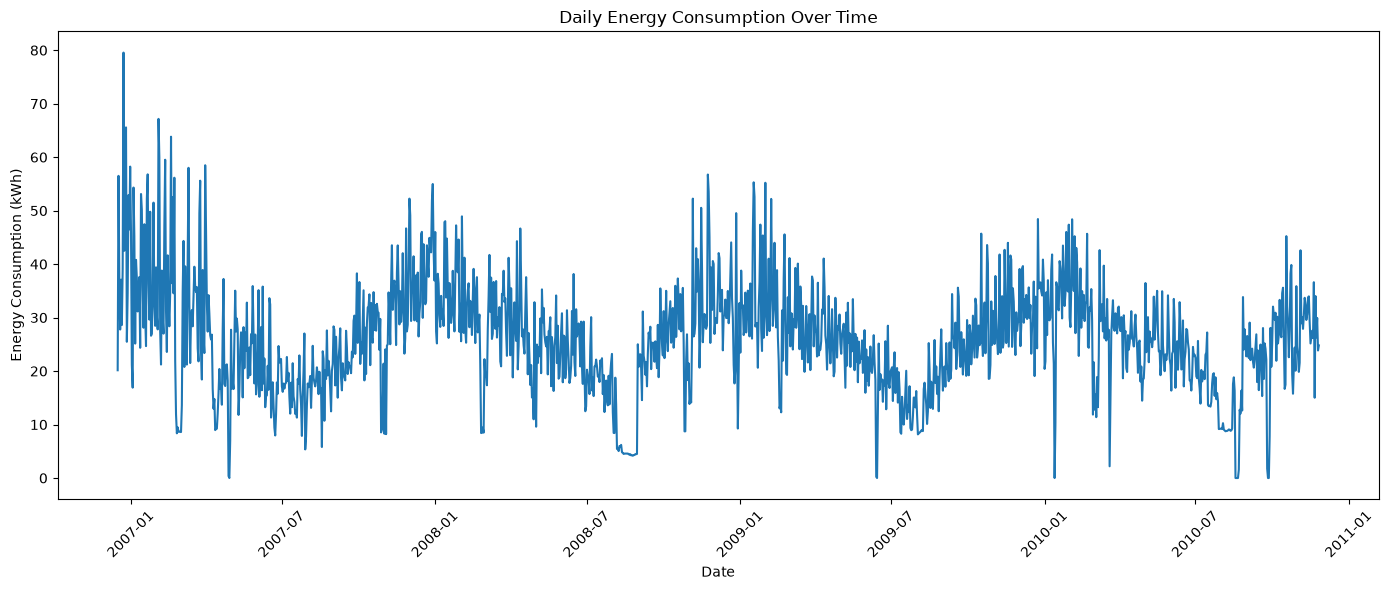

In [58]:
# Visualization
#Line chart to visualize daily energy consumption over time

plt.figure(figsize=(14, 6))

plt.plot(
    daily_energy["Datetime"],
    daily_energy["Energy_kWh"]
)

plt.title("Daily Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [59]:
#7 days movinf average to smooth out the daily fluctuations and highlight longer-term trends.

daily_energy["7_Day_MA"] = (
    daily_energy["Energy_kWh"]
    .rolling(window=7)
    .mean()
)

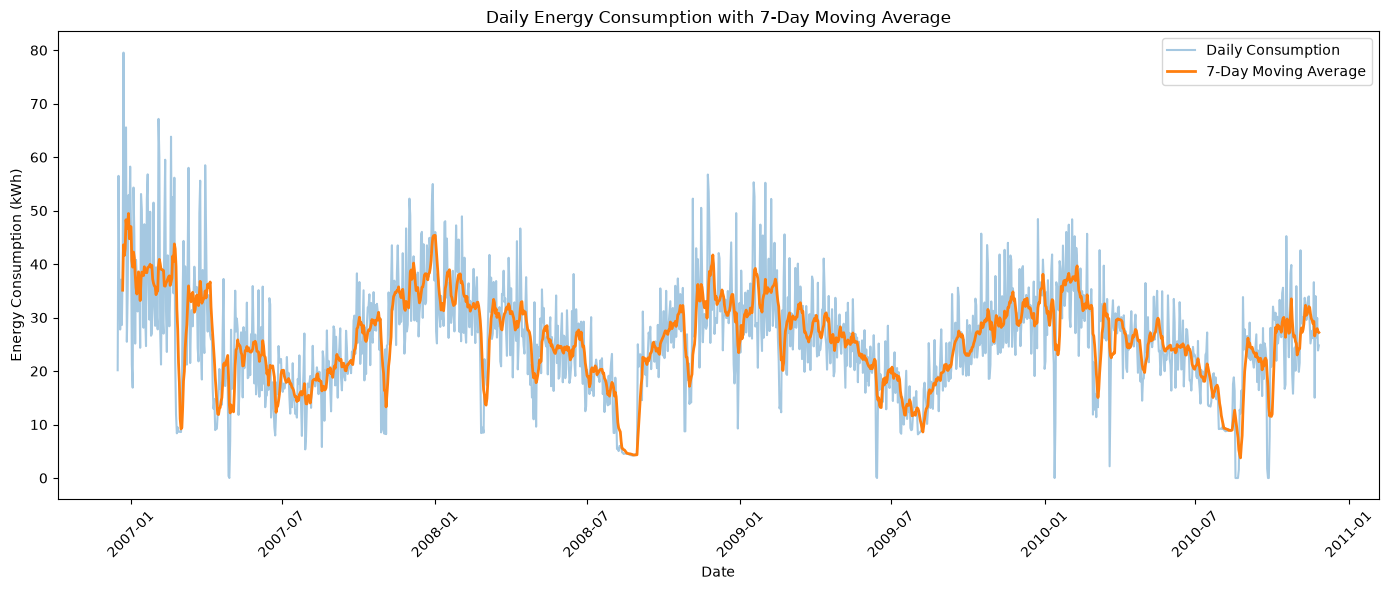

In [60]:
#New Plot for both daily energy consumption and 7-day moving average


plt.figure(figsize=(14, 6))

plt.plot(
    daily_energy["Datetime"],
    daily_energy["Energy_kWh"],
    alpha=0.4,
    label="Daily Consumption"
)

plt.plot(
    daily_energy["Datetime"],
    daily_energy["7_Day_MA"],
    linewidth=2,
    label="7-Day Moving Average"
)

plt.title("Daily Energy Consumption with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [61]:
#monthly energy consumption to identify seasonal patterns and trends.

monthly_energy = (
    df_clean
    .set_index("Datetime")["Energy_kWh"]
    .resample("MS")
    .sum()
    .reset_index()
)

monthly_energy.head()

,Datetime,Energy_kWh
0,2006-12-01,696.888033
1,2007-01-01,1150.197700
2,2007-02-01,941.481433
3,2007-03-01,981.036533
4,2007-04-01,586.357767


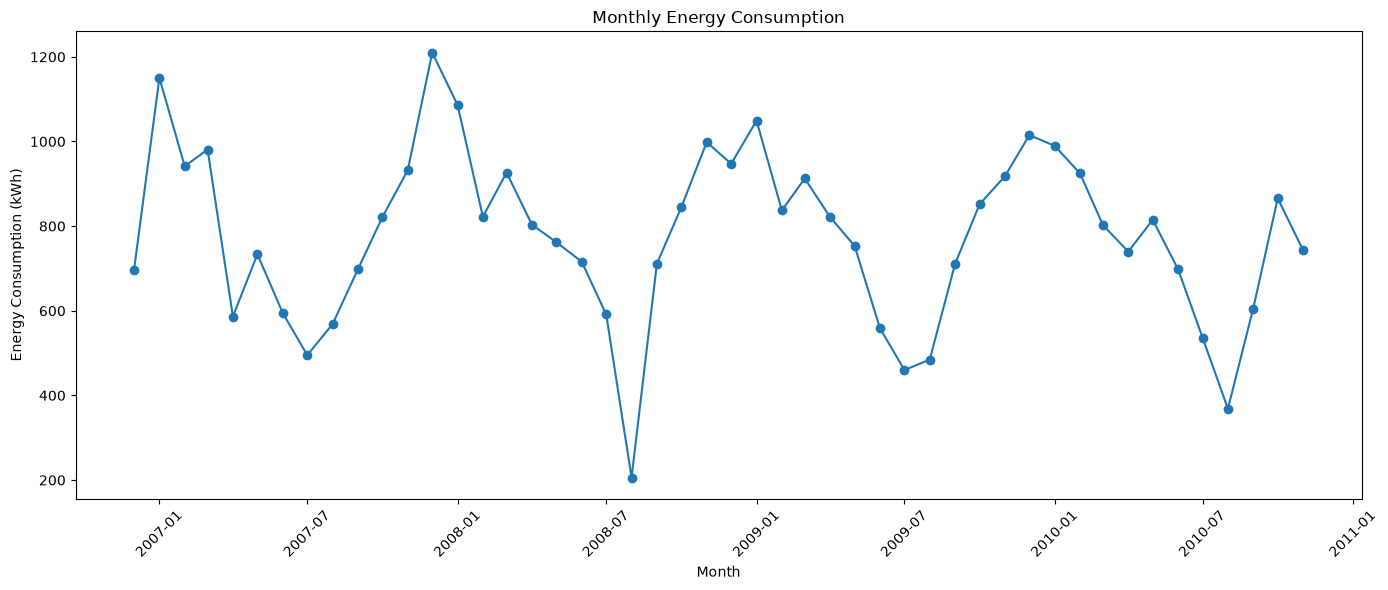

In [62]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_energy["Datetime"],
    monthly_energy["Energy_kWh"],
    marker="o"
)

plt.title("Monthly Energy Consumption")
plt.xlabel("Month")
plt.ylabel("Energy Consumption (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
#highest consumption month

highest_month = monthly_energy.loc[
    monthly_energy["Energy_kWh"].idxmax()
]

highest_month



Datetime      2007-12-01 00:00:00
Energy_kWh              1210.0695
Name: 12, dtype: object

In [65]:
#lowest consumption month

lowest_month = monthly_energy.loc[
    monthly_energy["Energy_kWh"].idxmin()
]

lowest_month

Datetime      2008-08-01 00:00:00
Energy_kWh                205.698
Name: 20, dtype: object

In [66]:
#Avg monthly consumption

print(
    "Average monthly consumption:",
    round(monthly_energy["Energy_kWh"].mean(), 2),
    "kWh"
)

Average monthly consumption: 776.74 kWh


In [67]:
#Peak Demand Hours

hourly_energy = (
    df_clean
    .groupby("Hour")["Global_active_power"]
    .mean()
    .reset_index()
)

hourly_energy

,Hour,Global_active_power
0,0,0.659434
1,1,0.539325
2,2,0.480621
3,3,0.444866
4,4,0.443847
5,5,0.453674
6,6,0.791600
7,7,1.502246
8,8,1.461016
9,9,1.331645


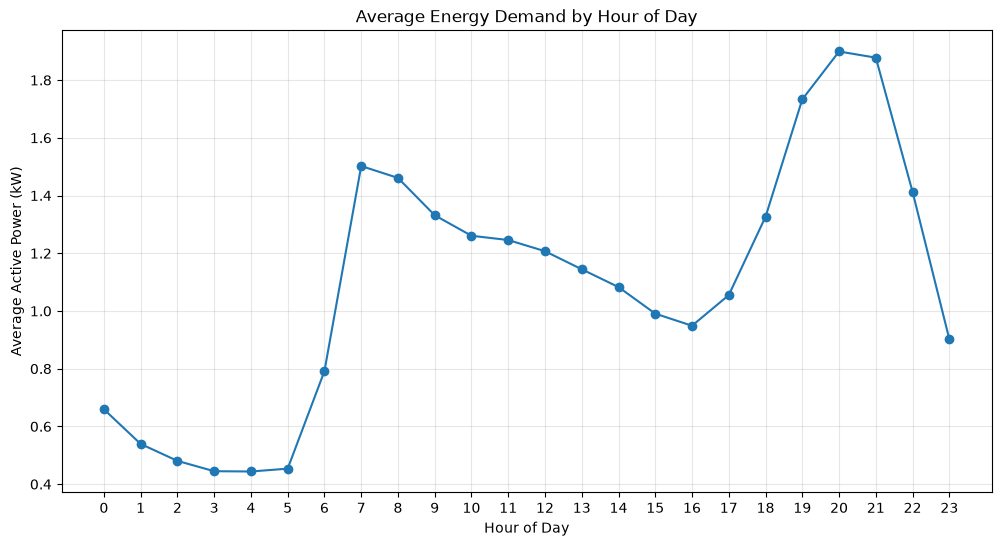

In [68]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_energy["Hour"],
    hourly_energy["Global_active_power"],
    marker="o"
)

plt.title("Average Energy Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Active Power (kW)")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()

In [69]:
#Peak hour

peak_hour = hourly_energy.loc[
    hourly_energy["Global_active_power"].idxmax()
]

peak_hour

Hour                   20.000000
Global_active_power     1.899064
Name: 20, dtype: float64

In [70]:
#Lowest demand hour

lowest_hour = hourly_energy.loc[
    hourly_energy["Global_active_power"].idxmin()
]

lowest_hour

Hour                   4.000000
Global_active_power    0.443847
Name: 4, dtype: float64

In [71]:
print(
    "Peak demand hour:",
    int(peak_hour["Hour"]),
    "with",
    round(peak_hour["Global_active_power"], 2),
    "kW average demand"
)

print(
    "Lowest demand hour:",
    int(lowest_hour["Hour"]),
    "with",
    round(lowest_hour["Global_active_power"], 2),
    "kW average demand"
)

Peak demand hour: 20 with 1.9 kW average demand
Lowest demand hour: 4 with 0.44 kW average demand


In [72]:
#Weekday vs Weekend Consumption

#Avg consumption

weekday_energy = (
    df_clean
    .groupby("Is_Weekend")["Global_active_power"]
    .mean()
    .reset_index()
)

weekday_energy

,Is_Weekend,Global_active_power
0,False,1.035472
1,True,1.234232


In [74]:
#Making the labels to understand easier.
weekday_energy["Day_Type"] = weekday_energy["Is_Weekend"].map({
    False: "Weekday",
    True: "Weekend"
})

weekday_energy

,Is_Weekend,Global_active_power,Day_Type
0,False,1.035472,Weekday
1,True,1.234232,Weekend


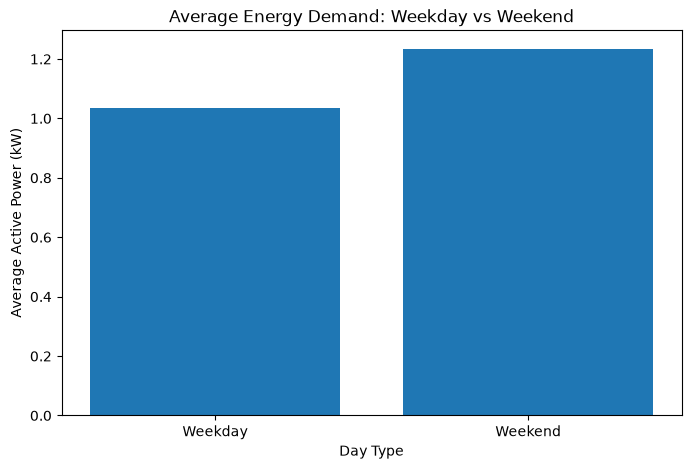

In [75]:
plt.figure(figsize=(8, 5))

plt.bar(
    weekday_energy["Day_Type"],
    weekday_energy["Global_active_power"]
)

plt.title("Average Energy Demand: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Active Power (kW)")

plt.show()

In [76]:
#Calculating th difference

weekday_avg = weekday_energy.loc[
    weekday_energy["Day_Type"] == "Weekday",
    "Global_active_power"
].iloc[0]

weekend_avg = weekday_energy.loc[
    weekday_energy["Day_Type"] == "Weekend",
    "Global_active_power"
].iloc[0]

difference = weekend_avg - weekday_avg

print("Weekday average:", round(weekday_avg, 2), "kW")
print("Weekend average:", round(weekend_avg, 2), "kW")
print("Difference:", round(difference, 2), "kW")

Weekday average: 1.04 kW
Weekend average: 1.23 kW
Difference: 0.2 kW


In [77]:
#Creating a correlation matrix

correlation = df_clean[measurement_columns].corr()

correlation

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Global_active_power,1.000000,0.247017,-0.399762,0.998889,0.484401,0.434569,0.638555
Global_reactive_power,0.247017,1.000000,-0.112246,0.266120,0.123111,0.139231,0.089617
Voltage,-0.399762,-0.112246,1.000000,-0.411363,-0.195976,-0.167405,-0.268172
Global_intensity,0.998889,0.266120,-0.411363,1.000000,0.489298,0.440347,0.626543
Sub_metering_1,0.484401,0.123111,-0.195976,0.489298,1.000000,0.054721,0.102571
Sub_metering_2,0.434569,0.139231,-0.167405,0.440347,0.054721,1.000000,0.080872
Sub_metering_3,0.638555,0.089617,-0.268172,0.626543,0.102571,0.080872,1.000000


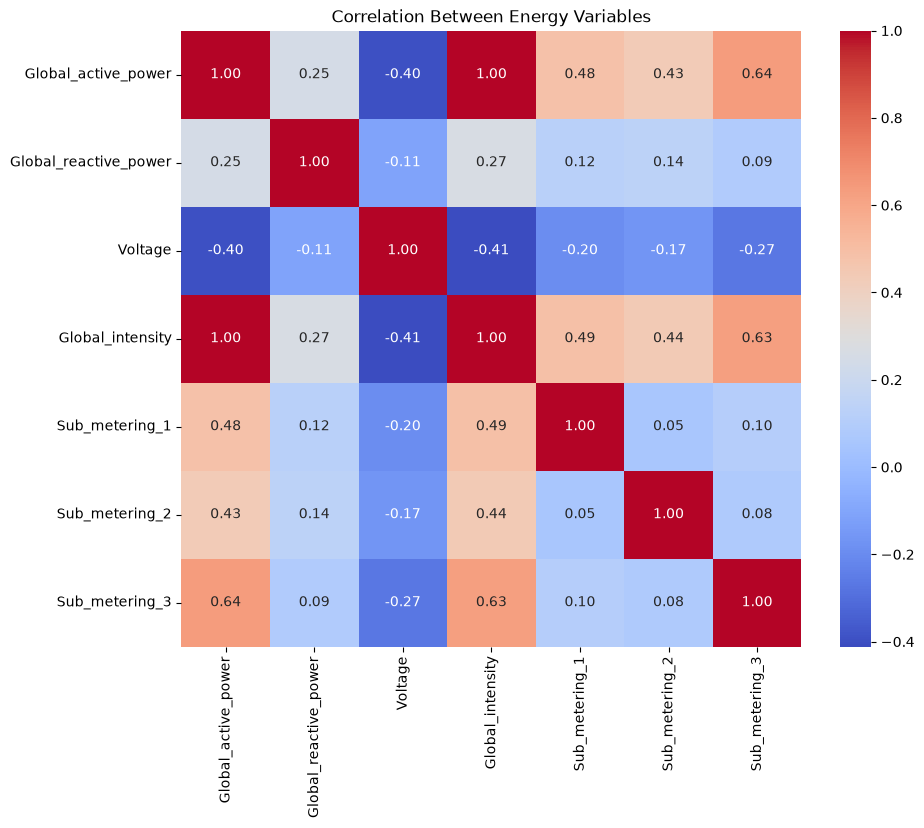

In [78]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Energy Variables")

plt.show()

In [79]:
#Strongest relationships

target_correlation = (
    correlation["Global_active_power"]
    .sort_values(ascending=False)
)

target_correlation

Global_active_power      1.000000
Global_intensity         0.998889
Sub_metering_3           0.638555
Sub_metering_1           0.484401
Sub_metering_2           0.434569
Global_reactive_power    0.247017
Voltage                 -0.399762
Name: Global_active_power, dtype: float64

In [80]:
#Basic statistics

consumption_stats = df_clean["Global_active_power"].describe()

consumption_stats

count    2.049280e+06
mean     1.091615e+00
std      1.057294e+00
min      7.600000e-02
25%      3.080000e-01
50%      6.020000e-01
75%      1.528000e+00
max      1.112200e+01
Name: Global_active_power, dtype: float64

In [81]:
mean_consumption = df_clean["Global_active_power"].mean()
median_consumption = df_clean["Global_active_power"].median()

print("Mean:", round(mean_consumption, 3), "kW")
print("Median:", round(median_consumption, 3), "kW")

Mean: 1.092 kW
Median: 0.602 kW


Detect unusually high consumption
We'll use the IQR method.

In [82]:
Q1 = df_clean["Global_active_power"].quantile(0.25)
Q3 = df_clean["Global_active_power"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 0.308
Q3: 1.528
IQR: 1.22


In [83]:
upper_limit = Q3 + 1.5 * IQR

print("Upper outlier threshold:", round(upper_limit, 3), "kW")

Upper outlier threshold: 3.358 kW


In [84]:
high_consumption = df_clean[
    df_clean["Global_active_power"] > upper_limit
]

print(
    "High-consumption observations:",
    len(high_consumption)
)

High-consumption observations: 94907


In [85]:
high_consumption[
    ["Datetime", "Global_active_power", "Voltage", "Global_intensity"]
].sort_values(
    "Global_active_power",
    ascending=False
).head(10)

,Datetime,Global_active_power,Voltage,Global_intensity
1150545,2009-02-22 17:09:00,11.122,229.78,48.4
112450,2007-03-04 19:34:00,10.670,230.20,46.4
112449,2007-03-04 19:33:00,10.650,229.97,46.4
1150544,2009-02-22 17:08:00,10.536,230.24,45.8
1029775,2008-11-30 20:19:00,10.348,231.60,44.6
968160,2008-10-19 01:24:00,10.290,230.90,44.6
586200,2008-01-27 19:24:00,10.162,229.16,44.2
112448,2007-03-04 19:32:00,10.154,229.72,44.4
1029773,2008-11-30 20:17:00,10.074,231.41,43.4
968161,2008-10-19 01:25:00,10.064,231.48,43.4


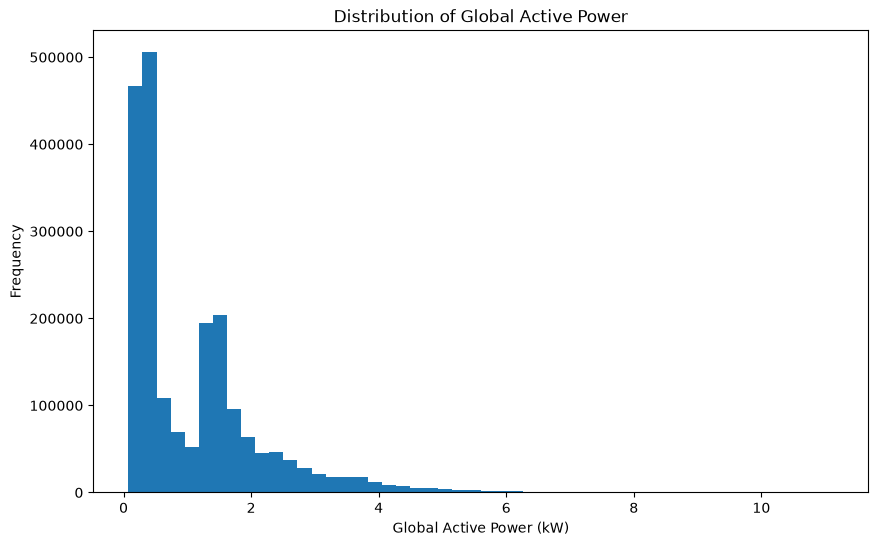

In [ ]:
#Consumption Distribution (Histogram)

plt.figure(figsize=(10, 6))

plt.hist(
    df_clean["Global_active_power"],
    bins=50
)

plt.title("Distribution of Global Active Power")
plt.xlabel("Global Active Power (kW)")
plt.ylabel("Frequency")

plt.show()

/var/folders/03/_z4xmjcs0_qd0w8qmsgkvtjc0000gn/T/ipykernel_6052/4145321368.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


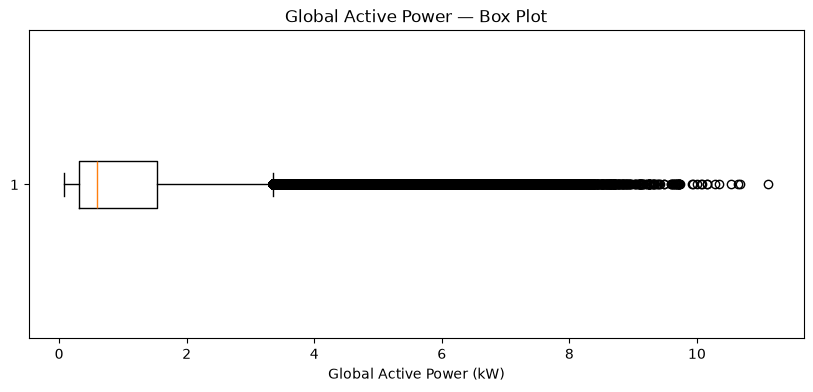

In [87]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    df_clean["Global_active_power"],
    vert=False
)

plt.title("Global Active Power — Box Plot")
plt.xlabel("Global Active Power (kW)")

plt.show()

## 4. Data Understanding — Final Summary

### Dataset
The project uses the UCI Individual Household Electric Power Consumption dataset containing minute-level electricity measurements collected over several years.

### Data Preparation
- Loaded the raw electricity dataset.
- Converted measurement columns to numeric format.
- Identified and handled missing measurements.
- Created a combined `Datetime` column.
- Created time-based features including Year, Month, Day, Hour, DayOfWeek, and Is_Weekend.
- Converted active power measurements into estimated energy consumption in kWh.

### Analysis Performed
- Daily energy consumption
- Monthly energy consumption
- Hourly demand patterns
- Weekday vs weekend comparison
- Correlation analysis
- Statistical distribution analysis
- High-consumption/outlier detection

### Key Analytical Questions
The next stage will investigate:
- When does electricity demand peak?
- Which periods have unusually high consumption?
- What seasonal patterns exist?
- Can future electricity demand be predicted using historical data?

### Next Notebook
The next notebook will focus on deeper exploratory analysis, feature engineering, and demand forecasting.

In [88]:
#Saving the processed dataset

processed_path = "data/processed/energy_consumption_clean.csv"

df_clean.to_csv(
    processed_path,
    index=False
)

print("Cleaned dataset saved successfully!")
print("Location:", processed_path)

Cleaned dataset saved successfully!
Location: data/processed/energy_consumption_clean.csv


In [89]:
import os

print(os.path.exists(processed_path))


True


In [90]:
file_size_mb = os.path.getsize(processed_path) / (1024 * 1024)

print("File size:", round(file_size_mb, 2), "MB")

File size: 217.23 MB


In [91]:
print(df_clean.shape)

(2049280, 17)
